In [1]:
# ============================================================
# Fixed-cluster / variable-apex grid experiment
# ============================================================
#
# Objetivo:
#   - Fijar el cúmulo en RA=0 deg, Dec=0 deg.
#   - Barrer el ápex en una grilla RA-Dec cada N grados.
#   - Simular el mismo cúmulo para cada ápex.
#   - Medir errores del análisis de polos / ápex.
#   - Guardar resultados en CSV.
#   - Graficar superficies de error.
#
# ============================================================

import sys
from pathlib import Path
from dataclasses import replace
from typing import Optional, Union

import numpy as np
import pandas as pd

from joblib import Parallel, delayed
from tqdm.auto import tqdm

import plotly.graph_objects as go
import matplotlib.pyplot as plt


In [2]:
# ============================================================
# Project path setup
# ============================================================

project_root = Path.cwd()

while project_root != project_root.parent and not (project_root / "src").exists():
    project_root = project_root.parent

if not (project_root / "src").exists():
    raise FileNotFoundError(
        "No se encontró la carpeta 'src' en el árbol de directorios."
    )

sys.path.insert(0, str(project_root.resolve()))

print("project_root:", project_root)
print("sys.path[0]:", sys.path[0])

project_root: c:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project
sys.path[0]: C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project


In [8]:
# ============================================================
# Project imports
# ============================================================

from src.simulacion_cumulo import (
    ClusterSimulationConfig,
    OpenClusterSimulator,
)
from src.utils import (
    show_cluster_validation_products_icrs,
    correct_gaia_proper_motions,
    plot_pm_vectors_on_sky,
    galactic_lb_to_unit_vectors,
    plot_apex_error_grid,
    plot_apex_error_scatter,
)

from src.vector_director import run_cluster_analysis_from_dataframe

In [4]:
# ============================================================
# Geometry utilities
# ============================================================

def angular_separation_radec_deg(
    ra1_deg: float,
    dec1_deg: float,
    ra2_deg: float,
    dec2_deg: float,
) -> float:
    """
    Calcula la separación angular entre dos puntos RA/Dec en grados.
    """

    ra1 = np.deg2rad(float(ra1_deg))
    dec1 = np.deg2rad(float(dec1_deg))
    ra2 = np.deg2rad(float(ra2_deg))
    dec2 = np.deg2rad(float(dec2_deg))

    cos_sep = (
        np.sin(dec1) * np.sin(dec2)
        + np.cos(dec1) * np.cos(dec2) * np.cos(ra2 - ra1)
    )

    cos_sep = np.clip(cos_sep, -1.0, 1.0)

    return float(np.rad2deg(np.arccos(cos_sep)))


def make_apex_ra_dec_grid(
    apex_ra_step_deg: float = 5.0,
    apex_dec_step_deg: float = 5.0,
    apex_dec_min_deg: float = -85.0,
    apex_dec_max_deg: float = 85.0,
) -> pd.DataFrame:
    """
    Construye una grilla regular en RA-Dec para el ápex.

    Se recomienda evitar exactamente Dec = ±90 deg porque en los polos
    todas las RA representan el mismo punto.
    """

    apex_ra_values = np.arange(0.0, 360.0, apex_ra_step_deg)

    apex_dec_values = np.arange(
        apex_dec_min_deg,
        apex_dec_max_deg + apex_dec_step_deg,
        apex_dec_step_deg,
    )

    rows = []

    for apex_dec in apex_dec_values:
        for apex_ra in apex_ra_values:
            rows.append(
                {
                    "apex_ra_deg": float(apex_ra),
                    "apex_dec_deg": float(apex_dec),
                }
            )

    return pd.DataFrame(rows)


# ============================================================
# Single simulation for one apex
# ============================================================

def simulate_and_measure_apex_error_for_apex(
    base_config: ClusterSimulationConfig,
    apex_ra_deg: float,
    apex_dec_deg: float,
    cluster_id: str,
    fixed_center_ra_deg: float = 0.0,
    fixed_center_dec_deg: float = 0.0,
    group_value: str = "1",
    seed: Optional[int] = None,
    metric_keys: Optional[Union[list[str], str]] = None,
) -> dict:
    """
    Simula un cúmulo con centro fijo y ápex variable.

    Cúmulo:
        center_ra_deg = fixed_center_ra_deg
        center_dec_deg = fixed_center_dec_deg

    Ápex:
        apex_ra_deg
        apex_dec_deg
    """

    if metric_keys is None:
        metric_keys = ["apex_initial_axis_error_true_deg"]

    if isinstance(metric_keys, str):
        metric_keys = [metric_keys]

    config = replace(
        base_config,

        # Cúmulo fijo
        center_ra_deg=float(fixed_center_ra_deg),
        center_dec_deg=float(fixed_center_dec_deg),
        center_l_deg=None,
        center_b_deg=None,

        # Ápex variable
        apex_ra_deg=float(apex_ra_deg),
        apex_dec_deg=float(apex_dec_deg),

        seed=seed,
    )

    lambda_center_apex_deg = angular_separation_radec_deg(
        fixed_center_ra_deg,
        fixed_center_dec_deg,
        apex_ra_deg,
        apex_dec_deg,
    )

    sin_lambda_center_apex = float(
        np.sin(np.deg2rad(lambda_center_apex_deg))
    )

    try:
        simulator = OpenClusterSimulator(config)
        catalog = simulator.simulate()

        catalog["cluster_id"] = cluster_id
        catalog["grupo"] = group_value

        result = run_cluster_analysis_from_dataframe(
            df=catalog,
            cluster_id=cluster_id,

            group_col="grupo",
            ra_col="ra",
            dec_col="dec",
            pmra_col="pmra",
            pmdec_col="pmdec",
            parallax_col="parallax",
            cluster_col="cluster_id",

            # Peso uniforme
            weight_fill_value=1,

            # Ápex verdadero de esta simulación
            true_apex_ra_deg=config.apex_ra_deg,
            true_apex_dec_deg=config.apex_dec_deg,
        )

        summary = result.get("summary", {})

        metric_values = {
            key: summary.get(key, np.nan)
            for key in metric_keys
        }

        return {
            "center_ra_deg": float(fixed_center_ra_deg),
            "center_dec_deg": float(fixed_center_dec_deg),

            "apex_ra_deg": float(apex_ra_deg),
            "apex_dec_deg": float(apex_dec_deg),

            "lambda_center_apex_deg": lambda_center_apex_deg,
            "sin_lambda_center_apex": sin_lambda_center_apex,

            "cluster_id": cluster_id,
            "seed": seed,

            **metric_values,

            "status": "ok",
            "error_message": "",
        }

    except Exception as exc:
        metric_values = {
            key: np.nan
            for key in metric_keys
        }

        return {
            "center_ra_deg": float(fixed_center_ra_deg),
            "center_dec_deg": float(fixed_center_dec_deg),

            "apex_ra_deg": float(apex_ra_deg),
            "apex_dec_deg": float(apex_dec_deg),

            "lambda_center_apex_deg": lambda_center_apex_deg,
            "sin_lambda_center_apex": sin_lambda_center_apex,

            "cluster_id": cluster_id,
            "seed": seed,

            **metric_values,

            "status": "failed",
            "error_message": repr(exc),
        }


# ============================================================
# Parallel grid runner
# ============================================================

def run_apex_error_apex_grid_parallel(
    base_config: ClusterSimulationConfig,
    fixed_center_ra_deg: float = 0.0,
    fixed_center_dec_deg: float = 0.0,
    apex_ra_step_deg: float = 5.0,
    apex_dec_step_deg: float = 5.0,
    apex_dec_min_deg: float = -85.0,
    apex_dec_max_deg: float = 85.0,
    n_realizations_per_apex: int = 1,
    base_seed: int = 42,
    metric_keys: Optional[Union[list[str], str]] = None,
    n_jobs: int = 2,
    show_progress: bool = True,
    same_cluster_seed_per_realization: bool = True,
) -> pd.DataFrame:
    """
    Ejecuta una grilla de ápex dejando fijo el centro del cúmulo.

    Parámetro importante:
    ---------------------
    same_cluster_seed_per_realization=True

    Esto hace que, para una misma realización Monte Carlo, todos los ápex
    usen el mismo seed. Así comparas principalmente el efecto geométrico
    del ápex, no una realización estelar distinta en cada punto de la grilla.
    """

    if metric_keys is None:
        metric_keys = ["rms_pole_residual_initial_deg"]

    if isinstance(metric_keys, str):
        metric_keys = [metric_keys]

    grid = make_apex_ra_dec_grid(
        apex_ra_step_deg=apex_ra_step_deg,
        apex_dec_step_deg=apex_dec_step_deg,
        apex_dec_min_deg=apex_dec_min_deg,
        apex_dec_max_deg=apex_dec_max_deg,
    )

    tasks = []
    counter = 0

    for _, row in grid.iterrows():
        apex_ra = float(row["apex_ra_deg"])
        apex_dec = float(row["apex_dec_deg"])

        for realization_id in range(int(n_realizations_per_apex)):
            counter += 1

            if same_cluster_seed_per_realization:
                seed = int(base_seed + realization_id)
            else:
                seed = int(base_seed + counter)

            cluster_id = (
                f"fixed_ra_{fixed_center_ra_deg:06.1f}"
                f"_dec_{fixed_center_dec_deg:+06.1f}"
                f"_apex_ra_{apex_ra:06.1f}"
                f"_apex_dec_{apex_dec:+06.1f}"
                f"_mc_{realization_id:03d}"
            )

            tasks.append(
                {
                    "center_ra_deg": float(fixed_center_ra_deg),
                    "center_dec_deg": float(fixed_center_dec_deg),
                    "apex_ra_deg": apex_ra,
                    "apex_dec_deg": apex_dec,
                    "cluster_id": cluster_id,
                    "seed": seed,
                    "realization_id": realization_id,
                }
            )

    iterator = tqdm(tasks, total=len(tasks)) if show_progress else tasks

    rows = Parallel(
        n_jobs=n_jobs,
        backend="loky",
        prefer="processes",
        verbose=0,
    )(
        delayed(simulate_and_measure_apex_error_for_apex)(
            base_config=base_config,
            apex_ra_deg=task["apex_ra_deg"],
            apex_dec_deg=task["apex_dec_deg"],
            cluster_id=task["cluster_id"],
            fixed_center_ra_deg=task["center_ra_deg"],
            fixed_center_dec_deg=task["center_dec_deg"],
            group_value="1",
            seed=task["seed"],
            metric_keys=metric_keys,
        )
        for task in iterator
    )

    results = pd.DataFrame(rows)

    task_df = pd.DataFrame(tasks)

    results = results.merge(
        task_df[
            [
                "center_ra_deg",
                "center_dec_deg",
                "apex_ra_deg",
                "apex_dec_deg",
                "cluster_id",
                "seed",
                "realization_id",
            ]
        ],
        on=[
            "center_ra_deg",
            "center_dec_deg",
            "apex_ra_deg",
            "apex_dec_deg",
            "cluster_id",
            "seed",
        ],
        how="left",
    )

    return results


# ============================================================
# Summary over realizations
# ============================================================

def summarize_apex_grid_results(
    results: pd.DataFrame,
    metric_keys: Union[list[str], str],
) -> pd.DataFrame:
    """
    Agrupa los resultados por posición del ápex y calcula media, mediana,
    desviación estándar y número de realizaciones válidas para cada métrica.
    """

    if isinstance(metric_keys, str):
        metric_keys = [metric_keys]

    group_cols = [
        "center_ra_deg",
        "center_dec_deg",
        "apex_ra_deg",
        "apex_dec_deg",
        "lambda_center_apex_deg",
        "sin_lambda_center_apex",
    ]

    agg_dict = {}

    for key in metric_keys:
        agg_dict[key] = ["mean", "median", "std", "count"]

    summary = (
        results
        .groupby(group_cols, dropna=False)
        .agg(agg_dict)
        .reset_index()
    )

    # Aplanar columnas MultiIndex
    flat_cols = []

    for col in summary.columns:
        if isinstance(col, tuple):
            if col[1] == "":
                flat_cols.append(col[0])
            else:
                flat_cols.append(f"{col[0]}_{col[1]}")
        else:
            flat_cols.append(col)

    summary.columns = flat_cols

    return summary


# ============================================================
# Plotting utilities
# ============================================================

def plot_apex_grid_error_surface_plotly(
    grid_data: pd.DataFrame,
    value_col: str,
    title: str = "Fixed cluster / variable apex error surface",
    colorscale: str = "Viridis",
):
    """
    Superficie 3D interactiva:
        X = Apex RA
        Y = Apex Dec
        Z = métrica de error
    """

    pivot = grid_data.pivot(
        index="apex_dec_deg",
        columns="apex_ra_deg",
        values=value_col,
    )

    apex_ra_values = pivot.columns.to_numpy(dtype=float)
    apex_dec_values = pivot.index.to_numpy(dtype=float)
    z_values = pivot.to_numpy(dtype=float)

    fig = go.Figure(
        data=[
            go.Surface(
                x=apex_ra_values,
                y=apex_dec_values,
                z=z_values,
                colorscale=colorscale,
                colorbar=dict(title=value_col),
                hovertemplate=(
                    "Apex RA: %{x:.1f} deg<br>"
                    "Apex Dec: %{y:.1f} deg<br>"
                    f"{value_col}: " + "%{z:.4f}<extra></extra>"
                ),
            )
        ]
    )

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="Apex RA [deg]",
            yaxis_title="Apex Dec [deg]",
            zaxis_title=value_col,
            xaxis=dict(range=[0, 360]),
            yaxis=dict(range=[-90, 90]),
        ),
        width=1000,
        height=720,
    )

    fig.show()

    return fig


def plot_apex_grid_error_heatmap_plotly(
    grid_data: pd.DataFrame,
    value_col: str,
    title: str = "Fixed cluster / variable apex error map",
    colorscale: str = "Viridis",
):
    """
    Mapa 2D interactivo:
        X = Apex RA
        Y = Apex Dec
        color = métrica de error
    """

    pivot = grid_data.pivot(
        index="apex_dec_deg",
        columns="apex_ra_deg",
        values=value_col,
    )

    apex_ra_values = pivot.columns.to_numpy(dtype=float)
    apex_dec_values = pivot.index.to_numpy(dtype=float)
    z_values = pivot.to_numpy(dtype=float)

    fig = go.Figure(
        data=[
            go.Heatmap(
                x=apex_ra_values,
                y=apex_dec_values,
                z=z_values,
                colorscale=colorscale,
                colorbar=dict(title=value_col),
                hovertemplate=(
                    "Apex RA: %{x:.1f} deg<br>"
                    "Apex Dec: %{y:.1f} deg<br>"
                    f"{value_col}: " + "%{z:.4f}<extra></extra>"
                ),
            )
        ]
    )

    fig.update_layout(
        title=title,
        xaxis_title="Apex RA [deg]",
        yaxis_title="Apex Dec [deg]",
        width=1000,
        height=600,
    )

    fig.show()

    return fig


def plot_metric_vs_lambda(
    grid_data: pd.DataFrame,
    value_col: str,
    title: Optional[str] = None,
):
    """
    Scatter de la métrica contra lambda, donde lambda es la separación angular
    entre el centro fijo del cúmulo y el ápex.
    """

    if title is None:
        title = f"{value_col} vs lambda"

    plt.figure(figsize=(8, 5))

    plt.scatter(
        grid_data["lambda_center_apex_deg"],
        grid_data[value_col],
        s=12,
        alpha=0.7,
    )

    plt.xlabel("Separación centro-ápex λ [deg]")
    plt.ylabel(value_col)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [5]:
# ============================================================
# Configuration
# ============================================================

GAIA_LIKE_PM_ERROR = dict(
    pmra_error_distribution="log10_triangular",
    pmra_error_log10_left=-3.0,
    pmra_error_log10_mode=-1.7,
    pmra_error_log10_right=0.0,

    # Relación empírica:
    # pmdec_error ≈ 0.7 * pmra_error
    pm_error_slope=0.7,

    # Correlación entre perturbaciones de pmra y pmdec.
    pmra_pmdec_corr=0.2,

    # Dispersión alrededor de la pendiente 0.7.
    pm_error_slope_logscatter=0.08,
)


config_fixed_cluster = ClusterSimulationConfig(
    n_members=455,

    # Este centro será reforzado también dentro del runner.
    center_ra_deg=0.0,
    center_dec_deg=0.0,

    distance_pc=85.0,
    radius_pc=5.0,

    # Este ápex será reemplazado por la grilla.
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Error en paralaje
    parallax_error_mas=0.03,

    # Errores Gaia-like en movimientos propios
    **GAIA_LIKE_PM_ERROR,

    # Dispersión física interna
    speed_sigma_kms=5.0,
)


METRIC_KEYS = [
    "apex_initial_axis_error_true_deg",
    "apex_refined_axis_error_true_deg",

    "rms_pole_residual_initial_deg",
    "rms_pole_residual_refined_deg",

    "theta_pole_axis_initial_rms_deg",
    "theta_pole_axis_refined_rms_deg",

    "theta_clip_n_iterations",
    "theta_clip_n_rejected",
    "theta_clip_final_threshold_deg",

    "sin_lambda_refined_median",

    "pole_apex_dot_refined_rms",

    "pole_apex_error_geom_signed_refined_rms_deg",
    "pole_apex_error_geom_abs_refined_rms_deg",

    "pole_apex_error_direction_signed_refined_rms_deg",
    "pole_apex_error_direction_abs_refined_rms_deg",

    "pole_apex_error_direction_inverse_signed_refined_rms_deg",
    "pole_apex_error_direction_inverse_abs_refined_rms_deg",
]

In [6]:
# ============================================================
# Run experiment
# ============================================================

results_apex_grid = run_apex_error_apex_grid_parallel(
    base_config=config_fixed_cluster,

    fixed_center_ra_deg=0.0,
    fixed_center_dec_deg=0.0,

    # Grilla del ápex cada 5 grados
    apex_ra_step_deg=5.0,
    apex_dec_step_deg=5.0,
    apex_dec_min_deg=-85.0,
    apex_dec_max_deg=85.0,

    n_realizations_per_apex=1,
    base_seed=42,

    metric_keys=METRIC_KEYS,

    n_jobs=6,
    show_progress=True,

    # Recomendado: mismo cúmulo base para cada ápex
    same_cluster_seed_per_realization=True,
)



  0%|          | 0/2520 [00:00<?, ?it/s]

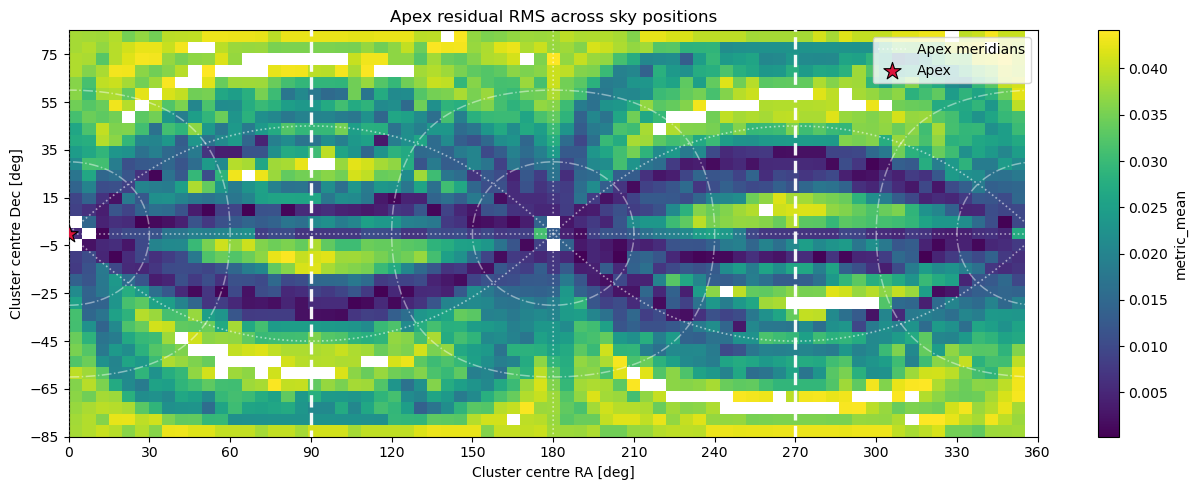

In [12]:
metric_key = "apex_refined_axis_error_true_deg"

apex_grid_summary = (
    results_apex_grid
    .groupby(["apex_ra_deg", "apex_dec_deg"], as_index=False)
    .agg(
        metric_mean=(metric_key, "mean"),
        metric_median=(metric_key, "median"),
        metric_std=(metric_key, "std"),
        metric_min=(metric_key, "min"),
        metric_max=(metric_key, "max"),
        n_total=(metric_key, "size"),
        n_valid=(metric_key, lambda x: np.isfinite(x).sum()),
        lambda_center_apex_deg=("lambda_center_apex_deg", "mean"),
        sin_lambda_center_apex=("sin_lambda_center_apex", "mean"),
    )
)

# Opcional: remover extremos altos para visualizar mejor
apex_grid_summary2 = apex_grid_summary[
    apex_grid_summary["metric_mean"]
    < apex_grid_summary["metric_mean"].quantile(0.96)
].copy()

# Adaptar columnas para reutilizar plot_apex_error_grid
apex_grid_for_plot = apex_grid_summary2.rename(
    columns={
        "apex_ra_deg": "center_ra_deg",
        "apex_dec_deg": "center_dec_deg",
    }
)

fig, ax = plot_apex_error_grid(
    apex_grid_for_plot,
    value_col="metric_mean",

    # En este caso este punto es el centro fijo del cúmulo, no el ápex.
    apex_ra_deg=0.0,
    apex_dec_deg=0.0,

    show_apex_equator=True,
    show_meridians=True,
    n_meridians=4,
    show_parallels=True,
    parallel_distances_deg=[30, 60, 120, 150],
)

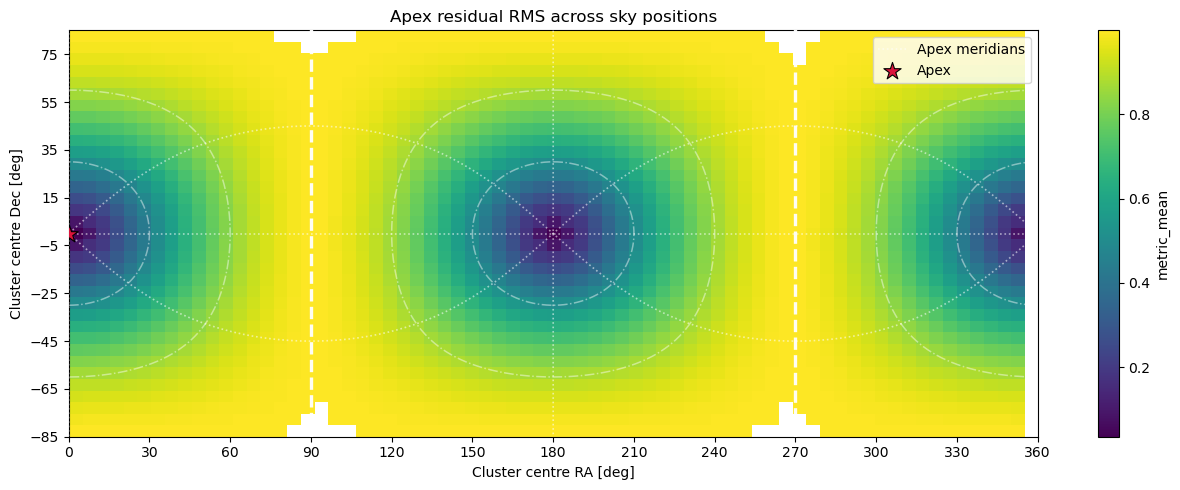

In [13]:
metric_key = "sin_lambda_refined_median"

apex_grid_summary = (
    results_apex_grid
    .groupby(["apex_ra_deg", "apex_dec_deg"], as_index=False)
    .agg(
        metric_mean=(metric_key, "mean"),
        metric_median=(metric_key, "median"),
        metric_std=(metric_key, "std"),
        metric_min=(metric_key, "min"),
        metric_max=(metric_key, "max"),
        n_total=(metric_key, "size"),
        n_valid=(metric_key, lambda x: np.isfinite(x).sum()),
        lambda_center_apex_deg=("lambda_center_apex_deg", "mean"),
        sin_lambda_center_apex=("sin_lambda_center_apex", "mean"),
    )
)

# Opcional: remover extremos altos para visualizar mejor
apex_grid_summary2 = apex_grid_summary[
    apex_grid_summary["metric_mean"]
    < apex_grid_summary["metric_mean"].quantile(0.96)
].copy()

# Adaptar columnas para reutilizar plot_apex_error_grid
apex_grid_for_plot = apex_grid_summary2.rename(
    columns={
        "apex_ra_deg": "center_ra_deg",
        "apex_dec_deg": "center_dec_deg",
    }
)

fig, ax = plot_apex_error_grid(
    apex_grid_for_plot,
    value_col="metric_mean",

    # En este caso este punto es el centro fijo del cúmulo, no el ápex.
    apex_ra_deg=0.0,
    apex_dec_deg=0.0,

    show_apex_equator=True,
    show_meridians=True,
    n_meridians=4,
    show_parallels=True,
    parallel_distances_deg=[30, 60, 120, 150],
)

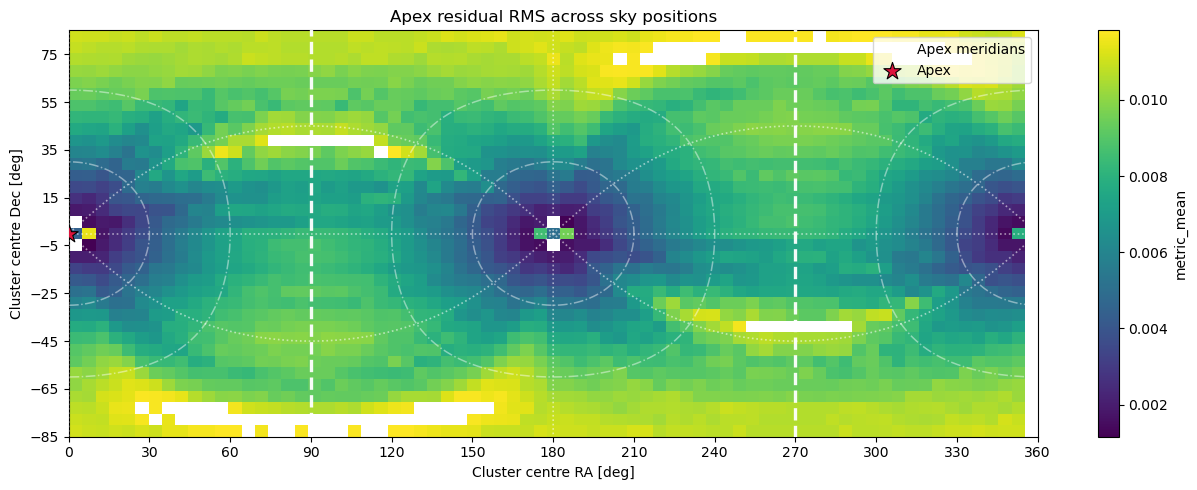

In [9]:
metric_key = "pole_apex_error_direction_inverse_signed_refined_rms_deg"

apex_grid_summary = (
    results_apex_grid
    .groupby(["apex_ra_deg", "apex_dec_deg"], as_index=False)
    .agg(
        metric_mean=(metric_key, "mean"),
        metric_median=(metric_key, "median"),
        metric_std=(metric_key, "std"),
        metric_min=(metric_key, "min"),
        metric_max=(metric_key, "max"),
        n_total=(metric_key, "size"),
        n_valid=(metric_key, lambda x: np.isfinite(x).sum()),
        lambda_center_apex_deg=("lambda_center_apex_deg", "mean"),
        sin_lambda_center_apex=("sin_lambda_center_apex", "mean"),
    )
)

# Opcional: remover extremos altos para visualizar mejor
apex_grid_summary2 = apex_grid_summary[
    apex_grid_summary["metric_mean"]
    < apex_grid_summary["metric_mean"].quantile(0.96)
].copy()

# Adaptar columnas para reutilizar plot_apex_error_grid
apex_grid_for_plot = apex_grid_summary2.rename(
    columns={
        "apex_ra_deg": "center_ra_deg",
        "apex_dec_deg": "center_dec_deg",
    }
)

fig, ax = plot_apex_error_grid(
    apex_grid_for_plot,
    value_col="metric_mean",

    # En este caso este punto es el centro fijo del cúmulo, no el ápex.
    apex_ra_deg=0.0,
    apex_dec_deg=0.0,

    show_apex_equator=True,
    show_meridians=True,
    n_meridians=4,
    show_parallels=True,
    parallel_distances_deg=[30, 60, 120, 150],
)